In [ ]:
# ==========================================
# Smart Email Classifier + Urgency Detection
# Dataset: final_enron_dataset.csv
# ==========================================

import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

from transformers import DistilBertForSequenceClassification, AutoTokenizer
from torch.optim import AdamW

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import random
import pickle

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ==========================================
# 1 Load Dataset
# ==========================================

df = pd.read_excel("/content/drive/MyDrive/AI BASEED EMAIL CLASSIFIER DATASET.xlsx")

print("Dataset shape:", df.shape)

# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Select required columns
df = df[['clean_text','category','urgency','split']]

# Drop null + empty
df.dropna(subset=['clean_text','category','urgency','split'], inplace=True)
df = df[df['clean_text'].str.strip() != ""]

# Reset index
df.reset_index(drop=True, inplace=True)

# Check split
print(df['split'].value_counts())

Dataset shape: (12717, 5)
split
train    10073
test      2644
Name: count, dtype: int64


Example mapping:
Complaint → 0
Feedback → 1
Request → 2
Spam → 3


In [ ]:
# ========================================== # 2 Encode Labels # ==========================================

from sklearn.preprocessing import LabelEncoder

# Normalize safely
df['category'] = df['category'].astype(str).str.lower().str.strip()
df['urgency'] = df['urgency'].astype(str).str.lower().str.strip()

#  CLEAN BEFORE ENCODING
df['category'] = df['category'].replace({
    'complaints': 'complaint',
    'req': 'request'
})

df['urgency'] = df['urgency'].replace({
    'urgent': 'high'
})

# CATEGORY
category_encoder = LabelEncoder()
df['category_label'] = category_encoder.fit_transform(df['category'])

# URGENCY
urgency_encoder = LabelEncoder()
df['urgency_label'] = urgency_encoder.fit_transform(df['urgency'])

# Print mappings
print("Category Mapping:", dict(zip(category_encoder.classes_, range(len(category_encoder.classes_)))))
print("Urgency Mapping:", dict(zip(urgency_encoder.classes_, range(len(urgency_encoder.classes_)))))

print(df[['category','category_label']].drop_duplicates())
print(df[['urgency','urgency_label']].drop_duplicates())

# Save encoders
with open("category_encoder.pkl", "wb") as f:
    pickle.dump(category_encoder, f)

with open("urgency_encoder.pkl", "wb") as f:
    pickle.dump(urgency_encoder, f)

Category Mapping: {'feedback': 0, 'request': 1, 'spam': 2}
Urgency Mapping: {'high': 0, 'low': 1, 'medium': 2}
   category  category_label
0  feedback               0
1      spam               2
4   request               1
  urgency  urgency_label
0     low              1
1    high              0
6  medium              2


### Train-Test Split

The dataset is divided into two parts:

Training Data – used to train the DistilBERT model.
Testing Data – used to evaluate the model performance.

Typically, 80% of the data is used for training and 20% for testing.
This ensures the model is evaluated on unseen data.

In [ ]:
# ==========================================
# 4 Train Test Split
# ==========================================

train_df = df[df['split'] == 'train']
test_df = df[df['split'] == 'test']

X_train_cat = train_df['clean_text']
y_train_cat = train_df['category_label']

X_test_cat = test_df['clean_text']
y_test_cat = test_df['category_label']

X_train_urg = train_df['clean_text']
y_train_urg = train_df['urgency_label']

X_test_urg = test_df['clean_text']
y_test_urg = test_df['urgency_label']



In [ ]:

# ==========================================
# 5 Tokenizer
# ==========================================
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

MAX_LEN = 256
BATCH_SIZE = 32
EPOCHS = 4

#random seed
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
# ==========================================
# 6 Dataset Class
# ==========================================

class EmailDataset(Dataset):

    def __init__(self, texts, labels):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):

        text = self.texts[idx]

        if pd.isna(text):
            text = ""

        label = int(self.labels[idx])

        encoding = tokenizer(
            text,
            max_length=MAX_LEN,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
            return_token_type_ids=False
        )

        encoding = {key: val.squeeze(0) for key, val in encoding.items()}

        return {
            "input_ids": encoding["input_ids"],
            "attention_mask": encoding["attention_mask"],
            "labels": torch.tensor(label, dtype=torch.long)
        }

In [ ]:
# ==========================================
# 7 DataLoaders
# ==========================================

#catagory dataloader
train_dataset_cat = EmailDataset(X_train_cat, y_train_cat)
val_dataset_cat = EmailDataset(X_test_cat, y_test_cat)

train_loader_cat = DataLoader(
    train_dataset_cat,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_cat = DataLoader(
    val_dataset_cat,
    batch_size=BATCH_SIZE,
    num_workers=2,
    pin_memory=True
)

#urgency dataloader
train_dataset_urg = EmailDataset(X_train_urg, y_train_urg)
val_dataset_urg = EmailDataset(X_test_urg, y_test_urg)

train_loader_urg = DataLoader(
    train_dataset_urg,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_urg = DataLoader(
    val_dataset_urg,
    batch_size=BATCH_SIZE,
    num_workers=2,
    pin_memory=True
)

In [ ]:
#RUN ONCE
#EXPECTED OUTPUT : (batch_size, MAX_LEN)(batch_size,)
batch = next(iter(train_loader_cat))

print(batch["input_ids"].shape)
print(batch["labels"].shape)

torch.Size([32, 256])
torch.Size([32])


In [ ]:
# ==========================================
# 8 Model initialization
# ==========================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# CATEGORY MODEL
model_cat = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(category_encoder.classes_)
).to(device)

optimizer_cat = AdamW(model_cat.parameters(), lr=2e-5)

# URGENCY MODEL
model_urg = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(urgency_encoder.classes_)
).to(device)

optimizer_urg = AdamW(model_urg.parameters(), lr=2e-5)

# LOSS
criterion = torch.nn.CrossEntropyLoss()

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
#check for catagory loader
batch = next(iter(train_loader_cat))

print(batch["input_ids"].shape)
print(batch["attention_mask"].shape)
print(batch["labels"].shape)

#check for urgency loader
batch = next(iter(train_loader_urg))

print(batch["input_ids"].shape)
print(batch["attention_mask"].shape)
print(batch["labels"].shape)

torch.Size([32, 256])
torch.Size([32, 256])
torch.Size([32])
torch.Size([32, 256])
torch.Size([32, 256])
torch.Size([32])


In [ ]:
# ==========================================
# 8 Training Catagory Model + Validation
# ==========================================
print("Training CATEGORY model...")
best_accuracy_cat = 0

for epoch in range(EPOCHS):

    model_cat.train()
    total_loss = 0

    for batch in train_loader_cat:

        optimizer_cat.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model_cat(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = criterion(outputs.logits, labels)

        total_loss += loss.item()

        loss.backward()
        optimizer_cat.step()

    avg_loss = total_loss / len(train_loader_cat)

    print(f"\n[Category] Epoch {epoch+1}/{EPOCHS}")
    print("Training Loss:", avg_loss)

    # Validation
    model_cat.eval()
    predictions, true_labels = [], []

    with torch.no_grad():
        for batch in val_loader_cat:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model_cat(input_ids=input_ids, attention_mask=attention_mask)

            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()

            predictions.extend(preds)
            true_labels.extend(batch["labels"].cpu().numpy())

    accuracy = accuracy_score(true_labels, predictions)
    print("Validation Accuracy:", accuracy)

    if accuracy > best_accuracy_cat:
        best_accuracy_cat = accuracy
        model_cat.save_pretrained("category_model")
        tokenizer.save_pretrained("category_model")
        print("Best CATEGORY model saved!")

Training CATEGORY model...

[Category] Epoch 1/4
Training Loss: 0.13296051891077132
Validation Accuracy: 0.99357034795764


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best CATEGORY model saved!

[Category] Epoch 2/4
Training Loss: 0.011488033482243145
Validation Accuracy: 0.9973524962178517


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best CATEGORY model saved!

[Category] Epoch 3/4
Training Loss: 0.0032637692403994383
Validation Accuracy: 0.9962178517397882

[Category] Epoch 4/4
Training Loss: 0.0012870763714003953
Validation Accuracy: 0.9969742813918305


In [ ]:
# ==========================================
# 8 Training Urgency Model + Validation
# ==========================================

print("Training URGENCY model...")
best_accuracy_urg = 0

for epoch in range(EPOCHS):

    model_urg.train()
    total_loss = 0

    for batch in train_loader_urg:

        optimizer_urg.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model_urg(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = criterion(outputs.logits, labels)

        total_loss += loss.item()

        loss.backward()
        optimizer_urg.step()

    avg_loss = total_loss / len(train_loader_urg)

    print(f"\n[Urgency] Epoch {epoch+1}/{EPOCHS}")
    print("Training Loss:", avg_loss)

    # Validation
    model_urg.eval()
    predictions, true_labels = [], []

    with torch.no_grad():
        for batch in val_loader_urg:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model_urg(input_ids=input_ids, attention_mask=attention_mask)

            preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()

            predictions.extend(preds)
            true_labels.extend(batch["labels"].cpu().numpy())

    accuracy = accuracy_score(true_labels, predictions)
    print("Validation Accuracy:", accuracy)

    if accuracy > best_accuracy_urg:
        best_accuracy_urg = accuracy
        model_urg.save_pretrained("urgency_model")
        tokenizer.save_pretrained("urgency_model")
        print("Best URGENCY model saved!")

Training URGENCY model...

[Urgency] Epoch 1/4
Training Loss: 0.32415311904180616
Validation Accuracy: 0.9731467473524962


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best URGENCY model saved!

[Urgency] Epoch 2/4
Training Loss: 0.06318418988218856
Validation Accuracy: 0.9807110438729199


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best URGENCY model saved!

[Urgency] Epoch 3/4
Training Loss: 0.027125597159038225
Validation Accuracy: 0.9848714069591528


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best URGENCY model saved!

[Urgency] Epoch 4/4
Training Loss: 0.023343400695612505
Validation Accuracy: 0.9882753403933434


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best URGENCY model saved!


In [ ]:
print("Best Category Accuracy:", best_accuracy_cat)
print("Best Urgency Accuracy:", best_accuracy_urg)

Best Category Accuracy: 0.9973524962178517
Best Urgency Accuracy: 0.9882753403933434


### Save Trained Model

After training, the trained model is saved to disk so it can be reused without retraining.

The following components are saved:
- DistilBERT model weights
- tokenizer
- category encoder
- urgency encoder

This enables the model to be loaded later for predictions.

In [ ]:


# ==========================================
# 10 catagory model Evaluation
# ==========================================

from sklearn.metrics import classification_report

model_cat.eval()

predictions_cat = []
true_labels_cat = []

with torch.no_grad():
    for batch in val_loader_cat:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model_cat(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()

        predictions_cat.extend(preds)
        true_labels_cat.extend(batch["labels"].cpu().numpy())

print("\n===== CATEGORY MODEL =====")
print(classification_report(
    true_labels_cat,
    predictions_cat,
    target_names=category_encoder.classes_
))


===== CATEGORY MODEL =====
              precision    recall  f1-score   support

    feedback       0.99      1.00      1.00       889
     request       1.00      1.00      1.00      1314
        spam       1.00      1.00      1.00       441

    accuracy                           1.00      2644
   macro avg       1.00      1.00      1.00      2644
weighted avg       1.00      1.00      1.00      2644



In [ ]:
# ==========================================
# 10 Urgency Evaluation
# ==========================================
model_urg.eval()

predictions_urg = []
true_labels_urg = []

with torch.no_grad():
    for batch in val_loader_urg:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model_urg(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        preds = torch.argmax(outputs.logits, dim=1).cpu().numpy()

        predictions_urg.extend(preds)
        true_labels_urg.extend(batch["labels"].cpu().numpy())

print("\n===== URGENCY MODEL =====")
print(classification_report(
    true_labels_urg,
    predictions_urg,
    target_names=urgency_encoder.classes_
))


===== URGENCY MODEL =====
              precision    recall  f1-score   support

        high       0.96      1.00      0.98       347
         low       1.00      1.00      1.00      1665
      medium       0.99      0.96      0.98       632

    accuracy                           0.99      2644
   macro avg       0.98      0.99      0.98      2644
weighted avg       0.99      0.99      0.99      2644



### Confusion Matrix Visualization

The confusion matrix provides a detailed view of model predictions.

Rows represent actual categories and columns represent predicted categories.

Correct predictions appear along the diagonal of the matrix, while off-diagonal values represent misclassifications.

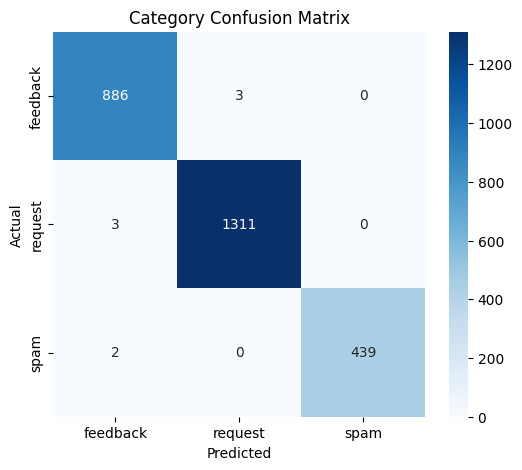

In [ ]:

# ==========================================
# 11 Catagory Confusion Matrix
# ==========================================

cm_cat = confusion_matrix(true_labels_cat, predictions_cat)

plt.figure(figsize=(6,5))
sns.heatmap(cm_cat, annot=True, fmt="d", cmap="Blues",
            xticklabels=category_encoder.classes_,
            yticklabels=category_encoder.classes_)

plt.title("Category Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

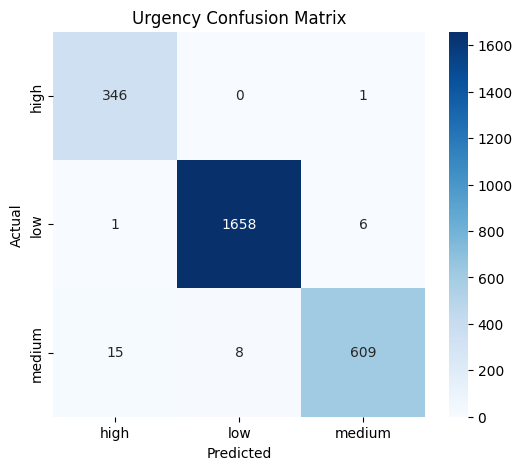

In [ ]:
# ==========================================
# 11 Urgency Confusion Matrix
# ==========================================
cm_urg = confusion_matrix(true_labels_urg, predictions_urg)

plt.figure(figsize=(6,5))
sns.heatmap(cm_urg, annot=True, fmt="d", cmap="Blues",
            xticklabels=urgency_encoder.classes_,
            yticklabels=urgency_encoder.classes_)

plt.title("Urgency Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# ==========================================
# 9 Save Model
# ==========================================

import os
import pickle

# Create folders
os.makedirs("category_model", exist_ok=True)
os.makedirs("urgency_model", exist_ok=True)

# =========================
# SAVE CATEGORY MODEL
# =========================
model_cat.save_pretrained("category_model")
tokenizer.save_pretrained("category_model")

with open("category_model/category_encoder.pkl", "wb") as f:
    pickle.dump(category_encoder, f)

# =========================
# SAVE URGENCY MODEL
# =========================
model_urg.save_pretrained("urgency_model")
tokenizer.save_pretrained("urgency_model")

with open("urgency_model/urgency_encoder.pkl", "wb") as f:
    pickle.dump(urgency_encoder, f)

print("Both models and encoders saved successfully.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Both models and encoders saved successfully.


### Rule-Based Urgency Detection

To improve urgency prediction, a rule-based system is used.

The system checks for urgent keywords such as:
urgent, asap, immediately, deadline, priority.

If these keywords are present in the email text, the urgency level is automatically set to HIGH.

In [ ]:
# ==========================================
# 12 Rule Based Urgency Detection
# ==========================================

def rule_based_urgency(text):

    text = text.lower()

    high_keywords = [
        "urgent", "asap", "immediate", "immediately",
        "action required", "immediate action",
        "payment failed", "account blocked",
        "security alert", "verify account",
        "login issue", "server down", "system failure",
        "secure account", "critical"
    ]

    medium_keywords = [
        "please respond", "kindly", "request",
        "verification code", "password reset",
        "account update", "follow up",
        "needed", "update required"
    ]

    low_keywords = [
    "offer", "discount", "sale",
    "shop now", "limited time",
    "use code", "promotion"
    ]

    def rule_based_urgency(text):

      text = text.lower()

    score = 0

    # HIGH
    for word in high_keywords:
        if word in text:
            score += 3

    # MEDIUM
    for word in medium_keywords:
        if word in text:
            score += 2

    # LOW
    for word in low_keywords:
        if word in text:
            score += 1

    if score >= 3:
        return "high"
    elif score == 2:
        return "medium"
    else:
        return "low"

In [ ]:
# ==========================================
# RULE-BASED CATEGORY (COMPLAINT DETECTION)
# ==========================================

def rule_based_complaint(text):

    text = text.lower()

    # 🔴 Strong complaint phrases (high confidence)
    strong_phrases = [
        "not working", "not responding", "completely broken",
        "very disappointed", "extremely unhappy",
        "worst experience", "this is unacceptable",
        "i want a refund", "refund my money",
        "service is terrible", "very poor service",
        "system is down", "server is down",
        "this is frustrating", "not satisfied at all",
        "highly disappointed", "failed to deliver"
    ]

    # 🟠 Moderate complaint keywords
    medium_keywords = [
        "issue", "problem", "error", "bug",
        "complaint", "delay", "fault", "failure",
        "not satisfied", "bad experience",
        "poor", "wrong", "crash", "unable",
        "doesn't work", "cannot", "can't"
    ]

    # 🟡 Negative sentiment words
    negative_words = [
        "bad", "worst", "terrible", "awful",
        "disappointed", "frustrated", "angry",
        "upset", "annoyed"
    ]

    score = 0

    # 🔴 Strong phrases → high weight
    for phrase in strong_phrases:
        if phrase in text:
            score += 3

    # 🟠 Medium keywords → medium weight
    for word in medium_keywords:
        if word in text:
            score += 2

    # 🟡 Negative sentiment → low weight
    for word in negative_words:
        if word in text:
            score += 1

    # 🎯 FINAL DECISION
    if score >= 4:
        return "complaint"

    return None

In [ ]:
# ==========================================
# 13 Hybrid Urgency Logic
# ==========================================

def final_urgency_prediction(text, ml_pred):

    rule_pred = rule_based_urgency(text)

    if rule_pred == "high":
        return "high"

    return urgency_encoder.inverse_transform([ml_pred])[0]

In [ ]:
#load model at the start
from transformers import DistilBertForSequenceClassification, AutoTokenizer

def load_models():

    global model_cat, model_urg, tokenizer
    global category_encoder, urgency_encoder
    global device

    try:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        print("Loading models...")

        # Tokenizer
        tokenizer = AutoTokenizer.from_pretrained("category_model")

        # Models
        model_cat = DistilBertForSequenceClassification.from_pretrained("category_model").to(device)
        model_urg = DistilBertForSequenceClassification.from_pretrained("urgency_model").to(device)

        model_cat.eval()
        model_urg.eval()

        # Encoders
        with open("category_model/category_encoder.pkl", "rb") as f:
            category_encoder = pickle.load(f)

        with open("urgency_model/urgency_encoder.pkl", "rb") as f:
            urgency_encoder = pickle.load(f)

        print("Models loaded successfully!")

    except Exception as e:
        print("Error loading models:", e)

In [ ]:
# ==========================================
# 14 Prediction Pipeline
# ==========================================

def predict_email(email_text):

    # Handle empty input
    if not email_text or not email_text.strip():
        return {
            "category": "unknown",
            "urgency": "low",
            "confidence": {
                "category": 0.0,
                "urgency": 0.0
            }
        }

    email_text = email_text.lower().strip()

    encoding = tokenizer(
        email_text,
        max_length=MAX_LEN,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    # CATEGORY (ML)
    model_cat.eval()
    with torch.no_grad():
        out_cat = model_cat(input_ids=input_ids, attention_mask=attention_mask)
        probs_cat = torch.softmax(out_cat.logits, dim=1)
        conf_cat, pred_cat = torch.max(probs_cat, dim=1)

    ml_category = category_encoder.inverse_transform([pred_cat.item()])[0]

    # 🔥 HYBRID OVERRIDE
    rule_category = rule_based_complaint(email_text)

    if rule_category is not None:
      category = "complaint"
      category_conf = 0.95   # fixed confidence for rule-based
    else:
      category = ml_category
      category_conf = conf_cat.item()

    # URGENCY (ML)
    model_urg.eval()
    with torch.no_grad():
        out_urg = model_urg(input_ids=input_ids, attention_mask=attention_mask)
        probs_urg = torch.softmax(out_urg.logits, dim=1)
        conf_urg, pred_urg = torch.max(probs_urg, dim=1)

    # HYBRID
    urgency = final_urgency_prediction(email_text, pred_urg.item())

    final_conf = max(category_conf, conf_urg.item())

    return {
        "category": category,
        "urgency": urgency,
        "confidence": round(final_conf, 3)
    }

In [ ]:
# @title
# ==========================================
# 15 Store Results
# ==========================================

import os

def store_result(email, category, urgency, confidence):

    data = {
        "Email_Text": email,
        "Predicted_Category": category,
        "Urgency_Level": urgency,
        "Confidence": confidence,
        "Timestamp": datetime.now()
    }

    result_df = pd.DataFrame([data])

    file_exists = os.path.isfile("classified_emails.csv")

    result_df.to_csv(
        "classified_emails.csv",
        mode="a",
        index=False,
        header=not file_exists
    )